## Evaluation Demo

In this workbook, you can reproduce the figures which we include in our paper. In particular, we demonstrate the following tests:

1. Input sequence length evaluation              ✅
2. Triplet vs. quadruplet training loss function ✅ -- but the results of this comparison aren't great (both are amazing) -- need to find worse scenarios
3. Fingerprint's temporal consistency            ✅ -- but we need to refactor everything to make it look more pretty
4. Multi-RX fingerprinting                       ⏳ -- practically the same thing as (2), but: multi-RX weight-based evaluation
5. Dataset confusion matrices                    ⏳ -- same as (4), but for both closed set and open set, and multi-RX weight-based

Requirements:

* Software: Matlab (tested with R2024a)
* Datasets: `DatasetAPI.DATASET_V2` and `DatasetAPI.DATASET_V4`

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import utils
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

2024-11-22 02:26:19.447617: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-22 02:26:19.447682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-22 02:26:19.448869: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-22 02:26:19.461170: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-22 02:26:20.149743: W tensorflow/compiler/tf2

### Let's pick a dataset

For this project, we captured two separate datasets in the Orbit testbed facility. Both serve the same purpose, but have a few differentiations:

* `DatasetAPI.DATASET_V2`: focuses on long-term signal capture (>24hrs), but compromises on the number of emitting devices (9-10 throughout epochs). Signal is captured from 4 receivers.
* `DatasetAPI.DATASET_V4`: focuses on shorter-term signal capture (~4hrs), but provides a larger number of available emitters (20 throughout epochs). Signal is captured from 3 receivers.

Select which one you'd like to use for this experiment, and all the configurations will be adjusted accordingly ()

In [2]:
DATASET_NAME = DatasetAPI.DATASET_V2 # also called Day 1
# DATASET_NAME = DatasetAPI.DATASET_V4 # also called Day 2
# DATASET_NAME = DatasetAPI.DATASET_V2V4

### Let's configure the system

In the cell below, we configure the settings for the system. Here's high-level overview of what these configs mean:

* `ROOT_DIRECTORY`: this is the root directory, where we expect to find all the datasets
* `MATLAB_SRC_DIRECTORY`: a directory in this project, where we can access the Matlab code for running data augmentation scripts
* `MATLAB_SESSION_ID`: a live Matlab session name, which we'll connect to for running augmentation scripts
* `DATA_CONFIG`: a dict with configurations for how to work with the dataset
* `AUG_CONFIG`: a dict with configurations for how to augment the dataset
* `MODEL_CONFIG`: a dict with configurations for how we'll train the fingerprint extractor model
* `RX_NODES`: a list of RX node names, which is different for different datasets

In [3]:
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_worklow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 2,
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 10]),
    'k_factor_bounds':   matlab.double([0, 10]),
    'awgn':              matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size':        32,
    'loss_type':         'triplet_loss',
    # 'loss_type':         'quadruplet_loss',
    'npair_type':        'samedev',
    # 'alpha':             1.1,
    'alpha': 0.5,
    'patience':          10,
    'fp_len':            512,
    'row':               80,
    'enable_ind':        True
}

# The only differences between the two datasets are the numbers of receivers from which
# we were able to capture the signal
if DATASET_NAME in [DatasetAPI.DATASET_V4, DatasetAPI.DATASET_V2V4]: RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_4]
else: RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]

### Next, we'll initialize the main APIs:

* `ExtractorAPI`: functions that are useful for working with the fingerprint extractor models (training, loading, etc)
* `DatasetAPI`: functions that are useful for working with the dataset (reading, filtration, transformation, etc)
* `FingerprintingAPI`: functions that are useful for running the fingerprinting tasks (vector similarity search, etc)
* `EvaluationAPI`: service functions for running experiments displayed in our paper, primarily invoked from this notebook

In [4]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

### Plot the model layers and testbed topology map

This step is optional, but if you'd like to explore the composition of the fingerprint extractor model, run the next cell. You will find two types of printout: a figure (using `visualkeras`) and a standard model summary printout in the terminal.

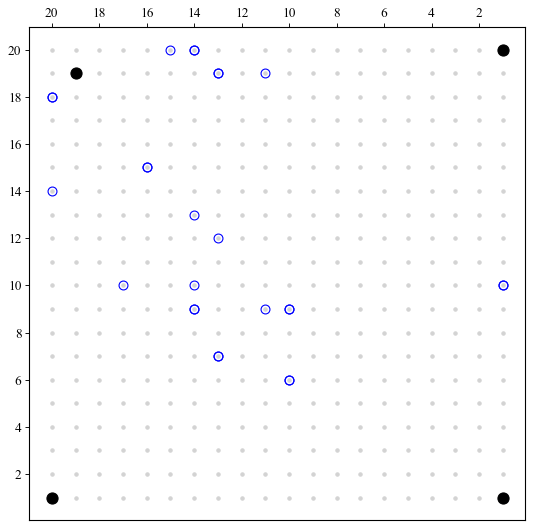

In [5]:
utils.apply_ieee_style()
eval_api.render_orbit_grid(
    tx_node_ids_1 = DatasetAPI.DATASET_V4_TX_MAX_DEVICES, 
    tx_node_ids_2 = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS, 
    rx_node_ids = [1, 20, 381, 379], 
    tx_node_id_curr = -1)

### Let's prepare the models

Here, you have two options:

* Option A: load pre-trained models (they would be stored in the `my_models` dir in the pre-processed dataset folder)
* Option B: train separate models for each RX from scratch (obviously, takes much longer to complete)

In [5]:
def get_extractor_models(fp_api, ndays, augment_multiplier, enable_training, plot_history, show_summary):
    # fp_api.train_models(apply_noise=False)
    if enable_training:
        models, histories = fp_api.train_models_mobrffi_v2v4(apply_noise=False, ndays=ndays, augment=True, augment_cfo=False, augment_multiplier=augment_multiplier)
        if plot_history and len(histories.values()) > 0:
            history = histories[RX_NODES[0]]
            plt.figure(figsize=(8, 6))
            plt.plot(history.history['loss'], label='Training Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title('Model Loss During Training')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.show()
        if show_summary and len(models.values()) > 0:
            models.values()[0].summary()

    else: 
        models = fp_api.load_models()

    return models

In [11]:
fp_api.train_models(apply_noise=False)

2024-11-21 19:47:57.468415: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 860 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0


Epoch 1/1000


2024-11-21 19:47:58.983152: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-11-21 19:48:00.759495: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa09a9f2b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-21 19:48:00.759523: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-21 19:48:00.763470: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1732236480.854287  175872 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


145/145 [==============================] - 7s 23ms/step - loss: 0.0408 - val_loss: 0.0062 - lr: 0.0010
Epoch 2/1000
145/145 [==============================] - 3s 18ms/step - loss: 0.0041 - val_loss: 7.1730e-04 - lr: 0.0010
Epoch 3/1000
145/145 [==============================] - 2s 17ms/step - loss: 0.0017 - val_loss: 0.0012 - lr: 0.0010
Epoch 4/1000
145/145 [==============================] - 2s 17ms/step - loss: 0.0011 - val_loss: 0.0022 - lr: 0.0010
Epoch 5/1000
145/145 [==============================] - 3s 18ms/step - loss: 6.5647e-04 - val_loss: 6.2432e-04 - lr: 0.0010
Epoch 6/1000
145/145 [==============================] - 2s 17ms/step - loss: 4.2204e-04 - val_loss: 1.3425e-04 - lr: 0.0010
Epoch 7/1000
145/145 [==============================] - 2s 17ms/step - loss: 4.0225e-04 - val_loss: 9.2150e-05 - lr: 0.0010
Epoch 8/1000
145/145 [==============================] - 3s 17ms/step - loss: 2.5368e-04 - val_loss: 3.0150e-04 - lr: 0.0010
Epoch 9/1000
145/145 [===========================

({'node1-1': <keras.src.engine.functional.Functional at 0x7fa53a7eace0>,
  'node1-20': <keras.src.engine.functional.Functional at 0x7fa40bd343d0>,
  'node20-1': <keras.src.engine.functional.Functional at 0x7fa40f63e1d0>,
  'node19-19': <keras.src.engine.functional.Functional at 0x7fa40ea57280>},
 {'node1-1': <keras.src.callbacks.History at 0x7fa5398ce890>,
  'node1-20': <keras.src.callbacks.History at 0x7fa532c077f0>,
  'node20-1': <keras.src.callbacks.History at 0x7fa40f63dde0>,
  'node19-19': <keras.src.callbacks.History at 0x7fa40ead4670>})

### Experiment 1. The impact of the preamble

To train the fingerprint extractor, we are using preambles of 802.11 frames. This raises a few questions:

* Why preambles? Why can't we use other sections of an OFDM frame
* Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?

To answer these questions, we perform the following experiments:

1. We train the model on 802.11 preambles, and test enrollment/identification on sections of frames with a shifting start index;
2. Next, we also try training the model on non-preamble section of a frame (index 400-800), and repeat the same testing plan.
3. Importantly, since we're performing simple A/B tests, we only evaluate performance for a closed-set problem (via KNN classification), for a single receiver, and for only two epochs.

These results can let us answer the questions above:

* **Why preambles? Why can't we use other sections of an OFDM frame** -- because this is the only section of a frame that doesn't contain "random" data. We can see this by reviewing the 2nd figure. Since the model was trained on non-preamble samples, the max accuracy the model ever achieves is 65%, which is not acceptable.

* **Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?** -- The model doesn't extract only hardware imperfections. The fingerprints incorporate data-specific features as well, which makes it essential to use the exact same preamble section for training & testing.

In [ ]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')


eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=0, offset_range=np.arange(0, 610, 1), use_pretrained=True, 
                                  fig_name="Preamble offset evaluation: preamble-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig1.eps'),
                                  enroll_device_idx = enroll_device_idx,
                                  identify_device_idx = identify_device_idx)
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=400, offset_range=np.arange(0, 610, 1), use_pretrained=False, 
                                  fig_name="Preamble offset evaluation: random data-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig2.eps'),
                                  enroll_device_idx = enroll_device_idx,
                                  identify_device_idx = identify_device_idx)

print('Done')

### 2. Experiment #2: Triplet vs. quadruplet training loss function

Every bit matters. Let's try adopting a quadruplet loss function and explore model performance on an identical dataset & settings.

Note: currently, the test is being performed under open-set conditions. You can override this by defining identical device ID sets in this function, and run closed-set test.

In [ ]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')

eval_api.evaluate_loss_function(rx_id = DatasetAPI.RX_1, fig_path = ROOT_DIRECTORY, enroll_device_idx=enroll_device_idx, identify_device_idx=identify_device_idx)

### Experiment 3. Fingerprint's temporal consistency

Generating eval finerprints for node1-1...
..........................................................................................................................................................................Generating eval finerprints for node1-20...
..........................................................................................................................................................................Generating eval finerprints for node20-1...
..........................................................................................................................................................................Generating eval finerprints for node19-19...
..........................................................................................................................................................................#39: STD[0.025576626143085743] VAR[0.000654163804863177]
#239: STD[0.04695687470657591] VAR[0.0022049480822090685]
#269: STD[0.02478383827281529

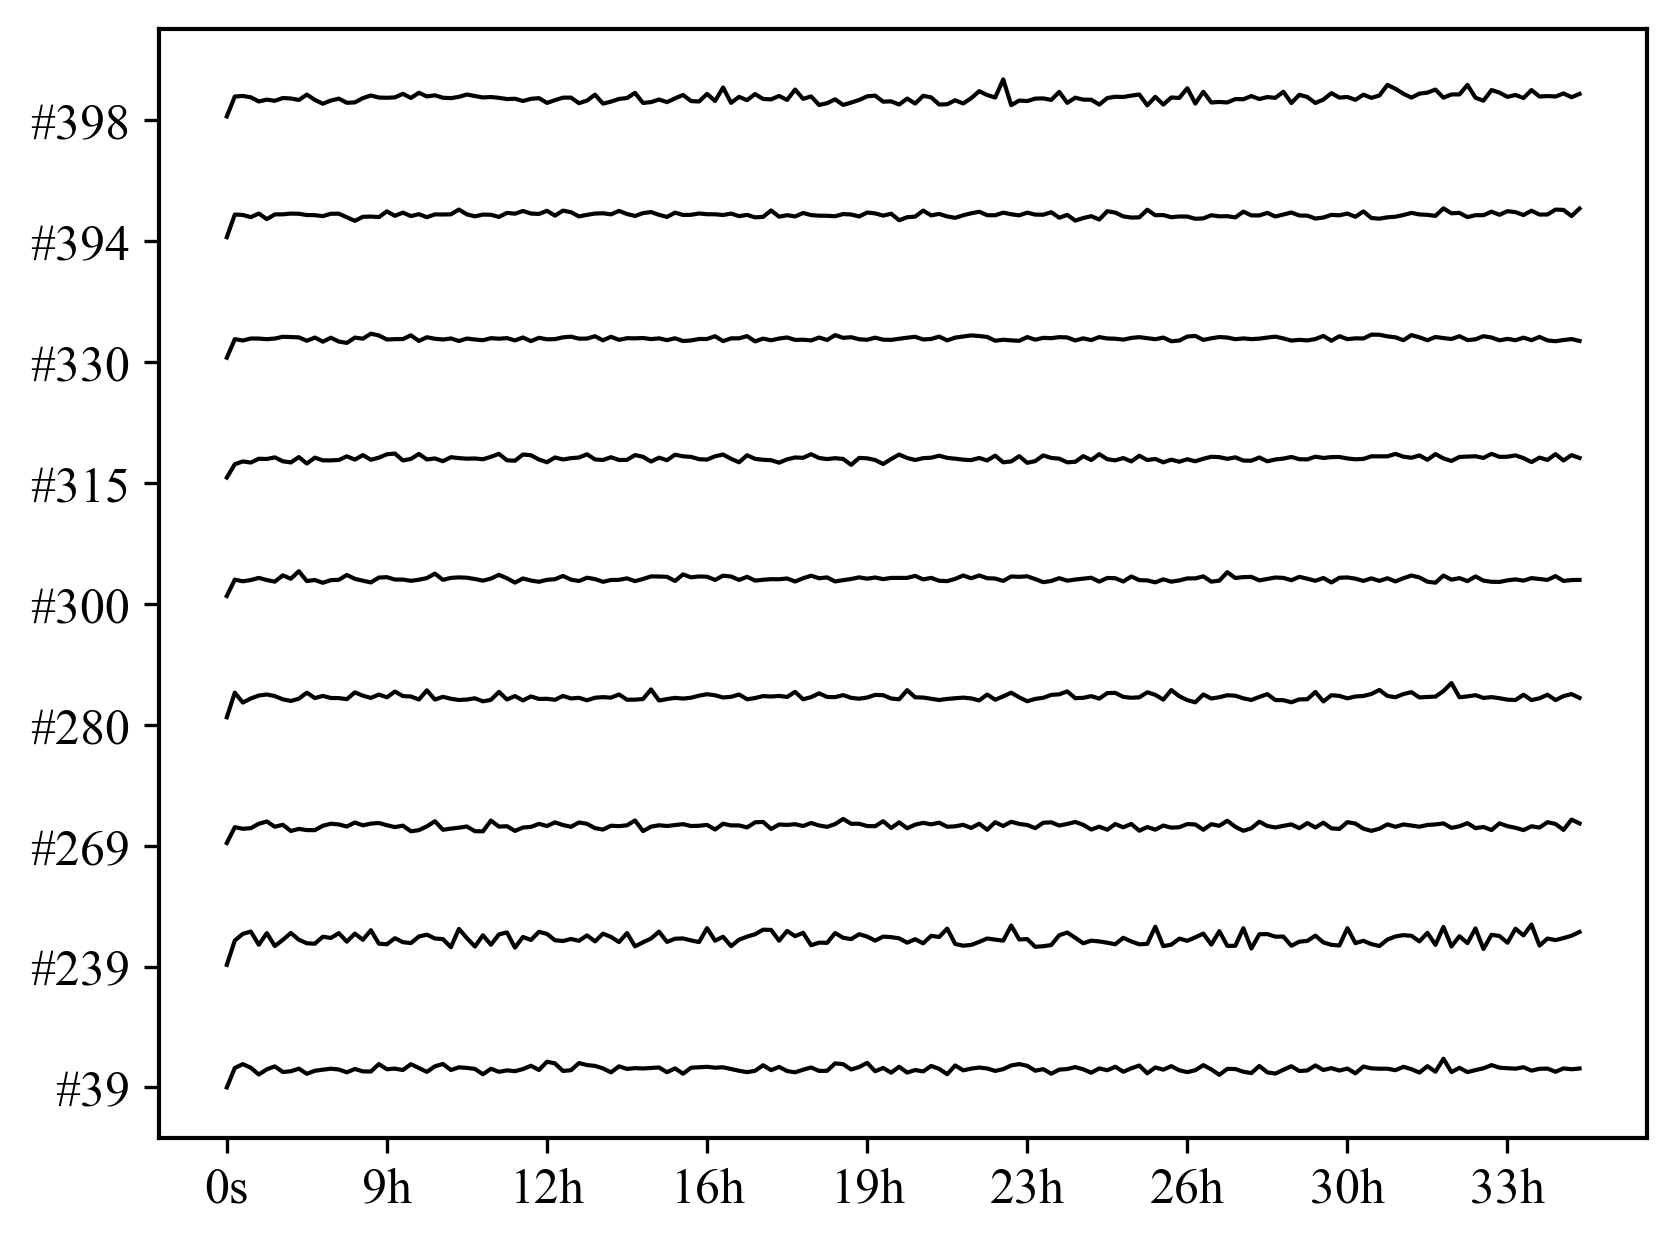

Re-identification threshold: 0.41715088973470926


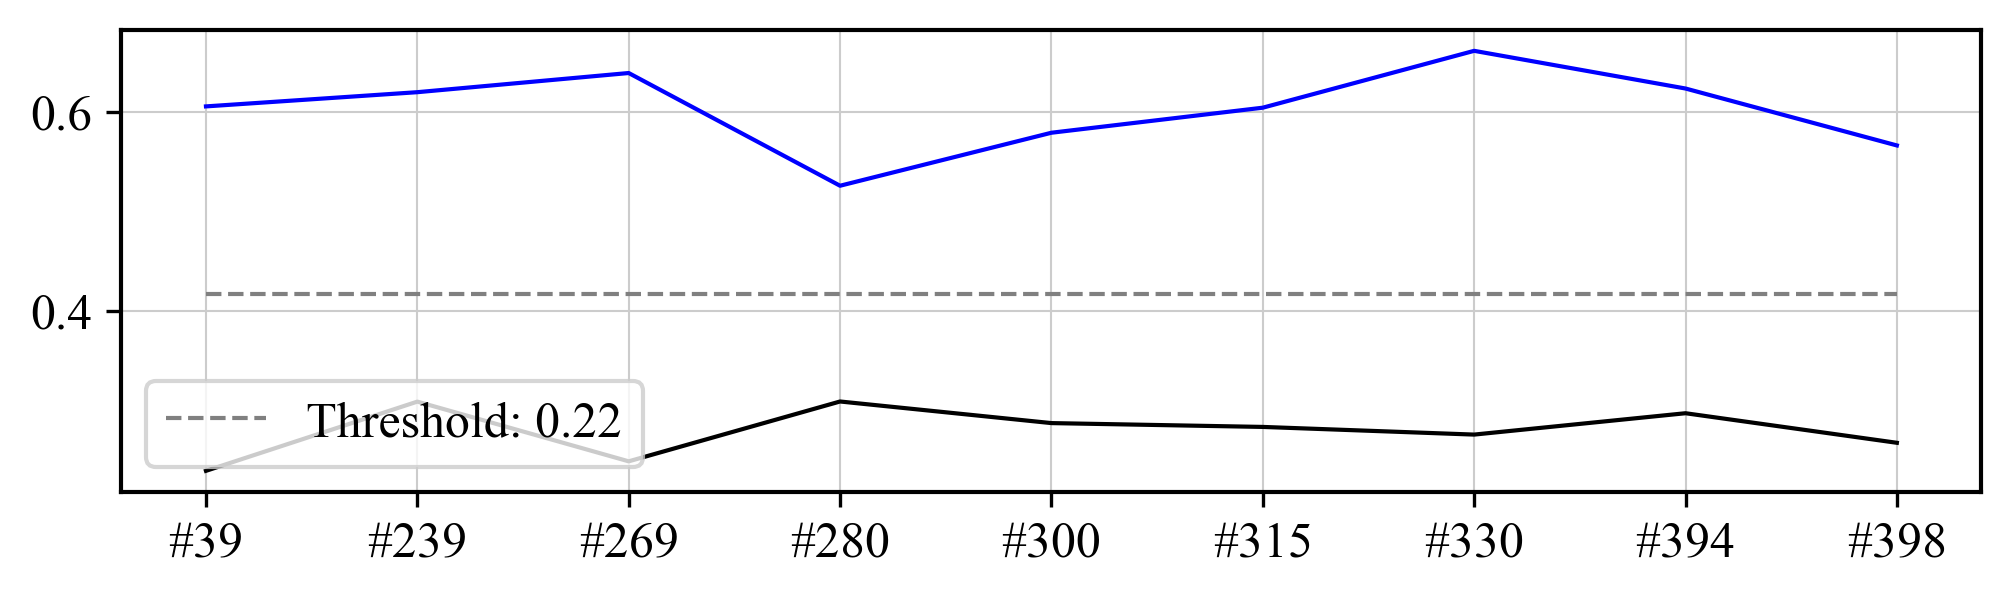

In [9]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    node_ids_epoch_override=DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    epochs_override=DatasetAPI.DATASET_V2_EPOCHS_MAX_DEVICES
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    node_ids_epoch_override=DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
    epochs_override=DatasetAPI.DATASET_V4_EPOCHS_MAX_DEVICES
else:
    print(f'No configs for {DATASET_NAME}')

# models, _ = fp_api.train_models(apply_noise=False)
models = fp_api.load_models()

fp_distances = eval_api.evaluate_temporal_stability(
    models, RX_NODES, 
    node_ids_epoch=node_ids_epoch_override, 
    epochs_override=epochs_override, 
    fig_path=ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=True, 
    rank_dist_fig_file = False)

### Experiment 4. Multi-RX fingerprinting

The task here is slightly more interesting. While previously we evaluated the process of training the model, as well as whether the model can extract time-insensitive features -- now we can consider whether it's possible to improve the system performance by combining (aka fusing) fingerprints from multiple receivers that "hear" our signal simultaneously. 

This requires a slightly different process. Previous model tests could be performed while using a simple KNN-based evaluator. This step requires building out a custom evaluator, which is going to let us combine KNN distances with our custom weight factor -- RSSI (normalized between 0 and 1 on a -100 to 0 dB scale). 

Here's how this evaluation will work: 

1. We will build an evaluator which performs the evaluation process using a custom list of receivers. 
2. We will then run this evaluator for the following combinations:
    * RX 1
    * RX 2
    * RX 3
    * RX 4
    * RX 1, 2
    * RX 1, 2, 3
    * rX 1, 2, 3, 4
3. We will compare their performance on both closed-set and open-set scenarios, and produce the same accuracy metrics as before
4. Optionally, we will let the user render a rank 1-2 plot across all devices

[39, 239, 269, 280, 300]
[39, 239, 269, 280, 300, 315, 330, 394, 398]
Load the training dataset for node1-1
Load the training dataset for node1-20
Load the training dataset for node20-1
Load the training dataset for node19-19
Generating eval finerprints for node1-20...
.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


.Re-identification threshold: 0.36129713416536274


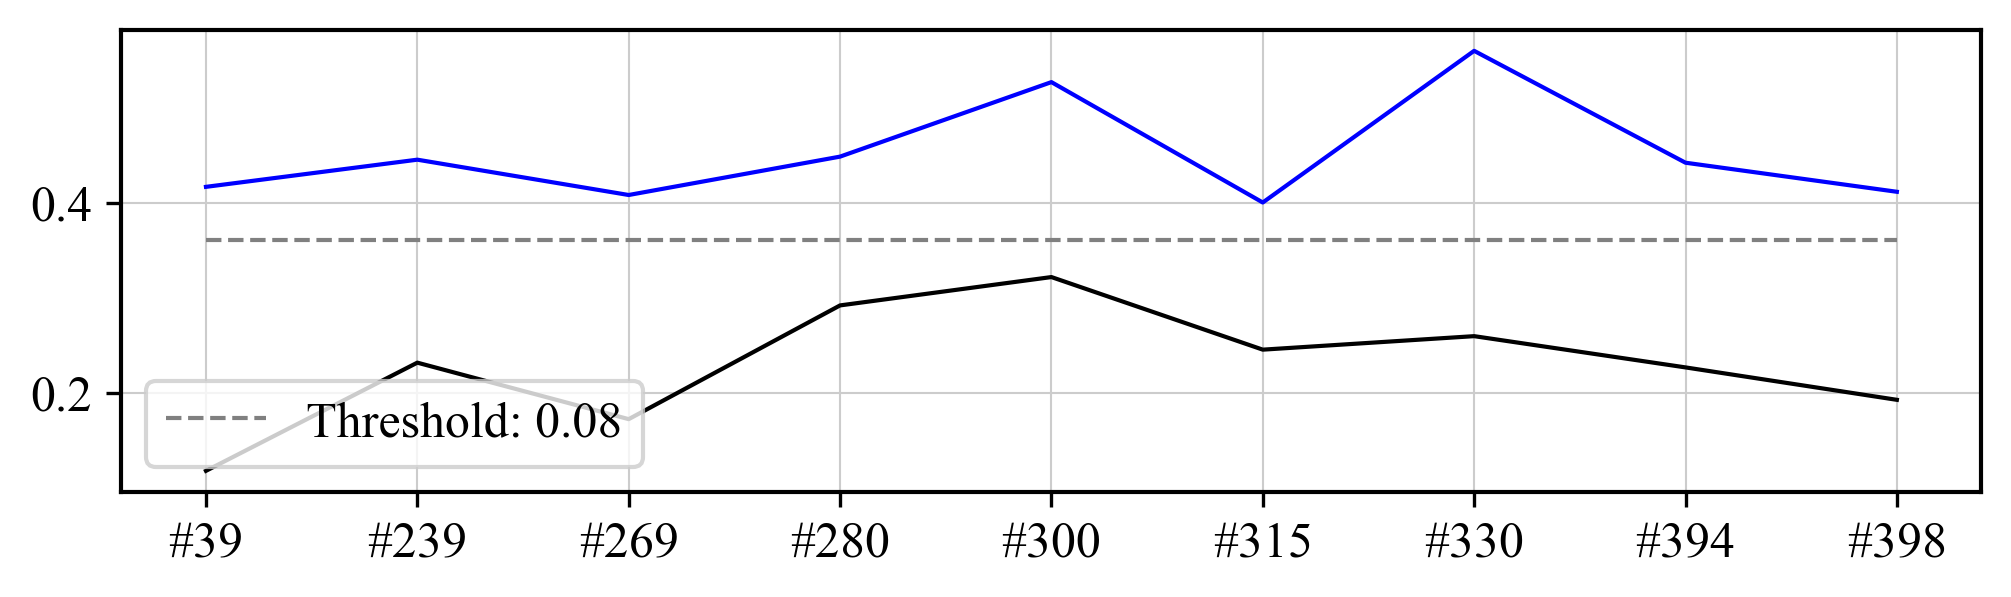

Generating eval finerprints for node1-1...
..Generating eval finerprints for node1-20...
.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


.Re-identification threshold: 0.3532281127667579


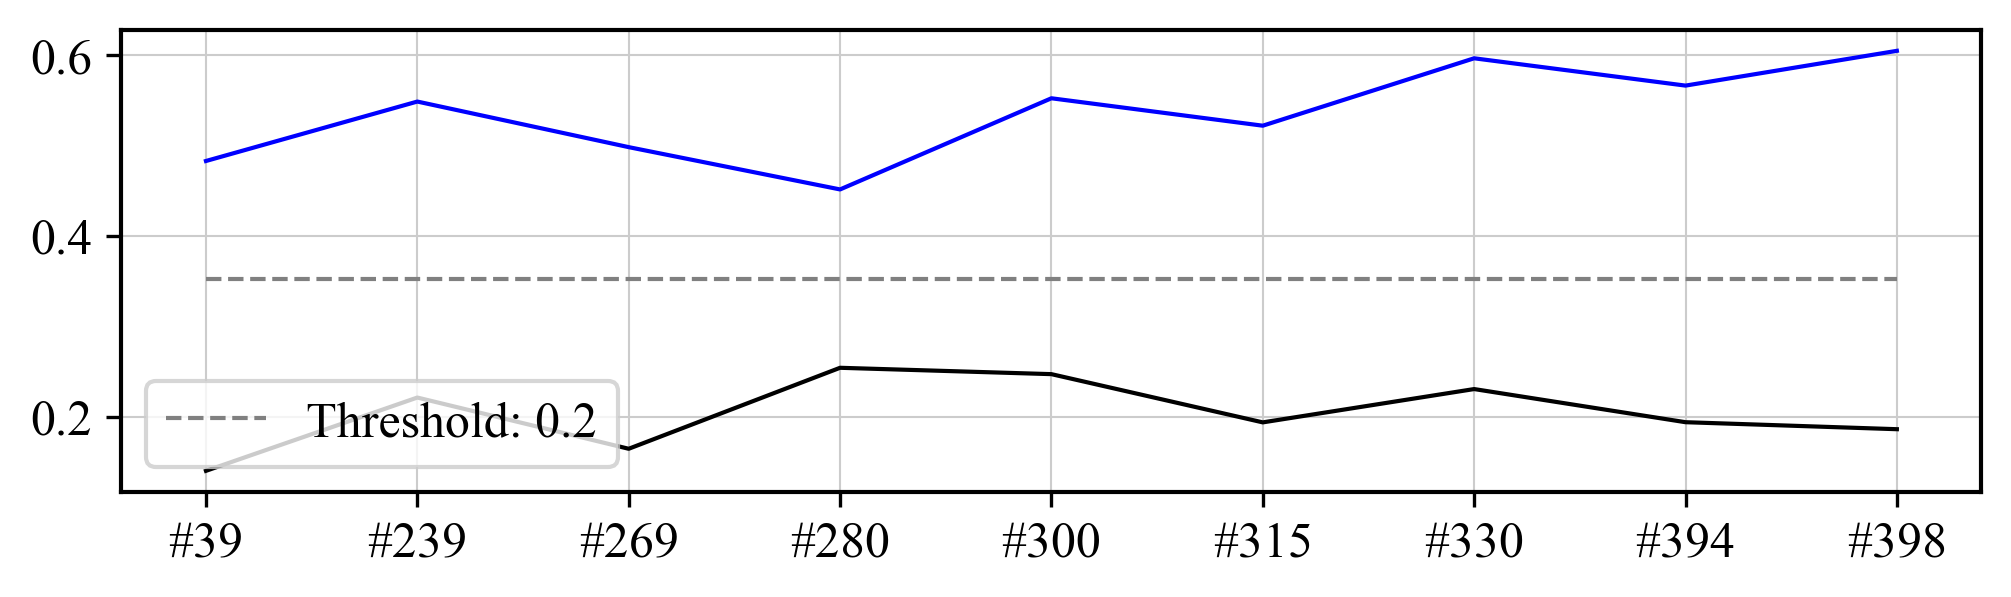

Generating eval finerprints for node1-1...
..Generating eval finerprints for node1-20...
..Generating eval finerprints for node20-1...
.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


.Re-identification threshold: 0.3682505010008674


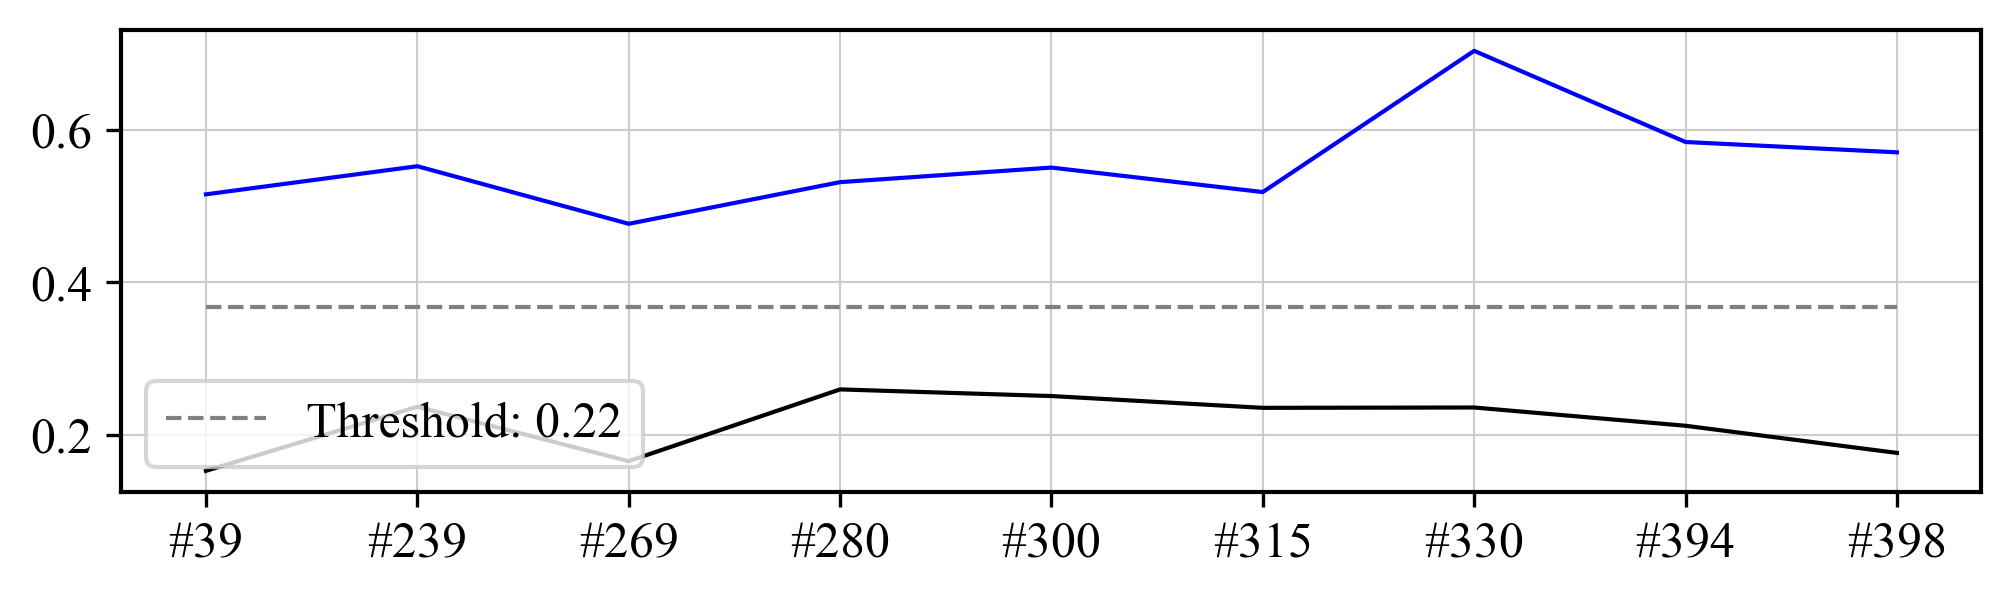

Generating eval finerprints for node1-1...
..Generating eval finerprints for node1-20...
..Generating eval finerprints for node20-1...
..Generating eval finerprints for node19-19...
.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


.Re-identification threshold: 0.39215738297629554


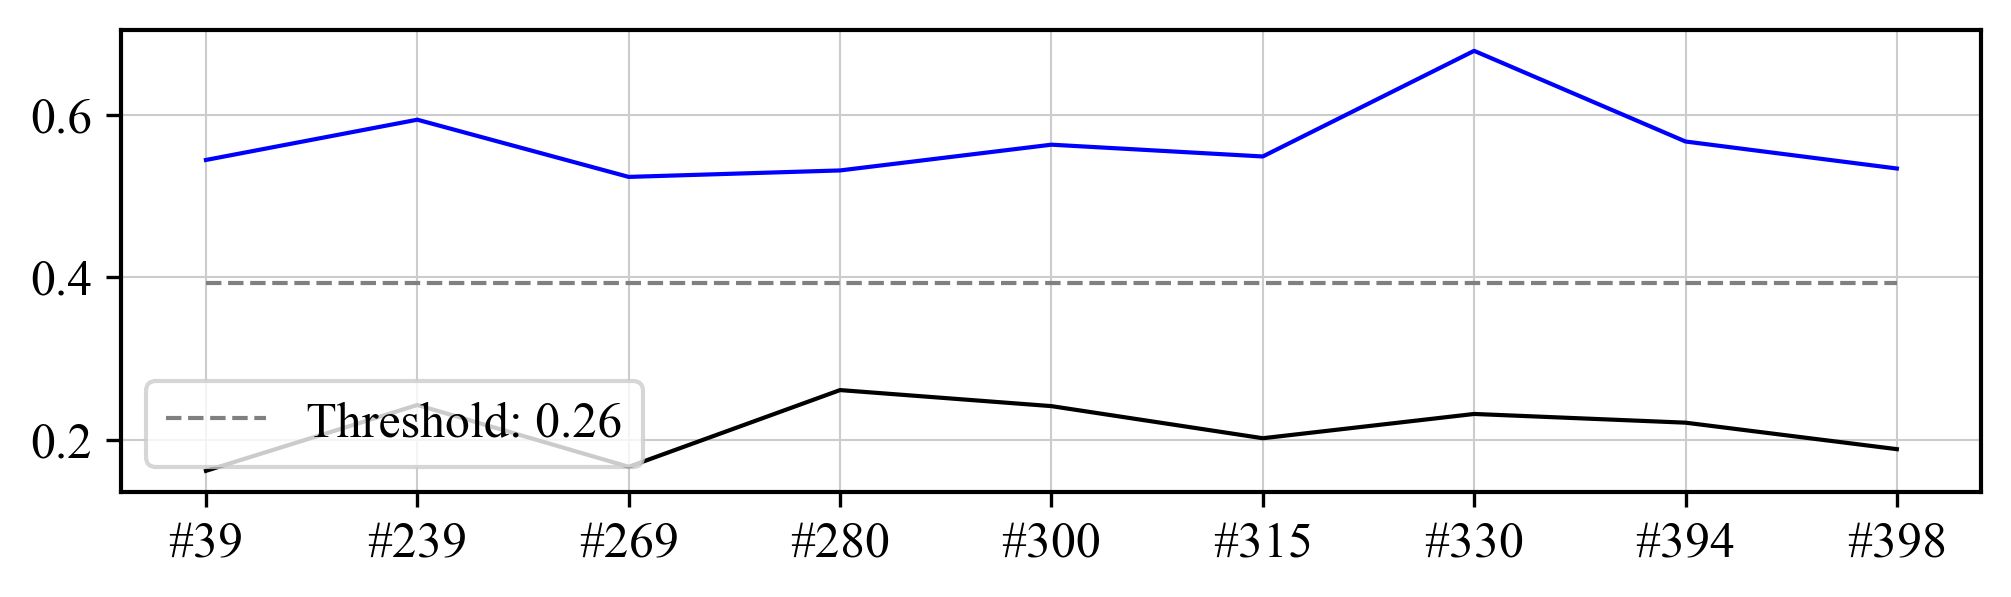

In [16]:
from dataset_preparation import awgn

if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')

print(enroll_device_idx)
print(identify_device_idx)

aug_on = False
apply_noise = False

epoch_idx_enroll = 0
epoch_idx_identify = 1

frame_count_enroll = frame_count_identify = 50

models = {}
data_epochs_1 = {}
labels_epochs_1 = {}
data_epochs_2 = {}
labels_epochs_2 = {}
rssis_epoch_2 = {}

for rx_id in RX_NODES:
    print(f"Load the training dataset for {rx_id}")
    dataset_train_path, dataset_epoch_paths, model_path, node_ids_train, _, samp_rate = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], rx_id, None)
    if aug_on: data, label, rssi = dataset_api.load_augmented_dataset(dataset_train_path, samp_rate, AUG_CONFIG, shuffle=True)
    else: data, label, rssi = dataset_api.load_raw_dataset(dataset_train_path, shuffle=True)
    data, label, rssi = dataset_api.filter_dataset(data, label, rssi, node_ids_train, np.arange(0, DATA_CONFIG['frame_count_train']))
    if apply_noise: data = awgn(data, np.arange(AUG_CONFIG['awgn'][0][0], AUG_CONFIG['awgn'][0][1]))
    data_train = data[:, 0:0+DATA_CONFIG['samples_count']]

    # feature_extractor, _ = extractor_api.train(data_train, label, node_ids_train, MODEL_CONFIG, save_path=None)
    models[rx_id] = extractor_api.load(os.path.join(model_path, f"extractor_{rx_id}.keras"))

    # Load data (two epochs: one to enroll devices, another to identify devices)
    data_enroll, labels_enroll, rssi_enroll = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_enroll], shuffle=True)
    data_identify, labels_identify, rssi_identify = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_identify], shuffle=True)

    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, rssi_enroll, dev_range=enroll_device_idx, pkt_range=np.arange(frame_count_enroll))
    data_identify, labels_identify, rssi_identify = dataset_api.filter_dataset(data_identify, labels_identify, rssi_identify, dev_range=identify_device_idx, pkt_range=np.arange(frame_count_identify))

    data_epochs_1[rx_id] = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    data_epochs_2[rx_id] = data_identify[:, 0:DATA_CONFIG['samples_count']]

    labels_epochs_1[rx_id] = labels_enroll
    labels_epochs_2[rx_id] = labels_identify

    rssis_epoch_2[rx_id] = rssi_identify

if DATASET_NAME == DatasetAPI.DATASET_V2:
    epochs = [
        'epoch_2024-07-20_01-15-26',
        'epoch_2024-07-20_01-25-24']
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    epochs = [
        'epoch_2024-08-08_19-19-27',
        'epoch_2024-08-08_19-59-37']
else:
    print(f'No configs for {DATASET_NAME}')

fp_distances_1 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[1:2], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_1.eps')

fp_distances_2 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:2], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_12.eps')

fp_distances_3 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:3], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_123.eps')

fp_distances_4 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:4], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_1234.eps')

### Experiment 4. Multi-RX Multi-day Closed-Set Fingerprinting

### IMPORTANT: this section requires you to re-load the libraries and settings wtih `DatasetAPI.DatasetV2V4`

Enrolling device 269: (14, 9)
This is a new device. New ID: 3443c82a-fe22-4eb3-97b3-458cd4a56b07
Enrolling device 398: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 455e26f7-2e5f-4d6b-af5e-5de3744ae681
Enrolling device 280: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 806c0e9c-dd85-4782-9691-d6d06a18cec4
Enrolling device 315: (16, 15)
This is a new device. New ID: 2fcab489-0598-40dc-844b-a1d6121dcbb1
Enrolling device 394: (20, 14)
This is a new device. New ID: e6c16436-ef91-4b2e-8aaf-a2c39f3cafa7
Enrolling device 300: (15, 20)
This is a new device. New ID: 5e21357d-5fe9-4442-9c5c-b7f27d5a75dd
Enrolling device 330: (17, 10)
This is a new device. New ID: affad339-5fe1-4309-a04c-761d2f3afe57
E1. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (16, 15)
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||

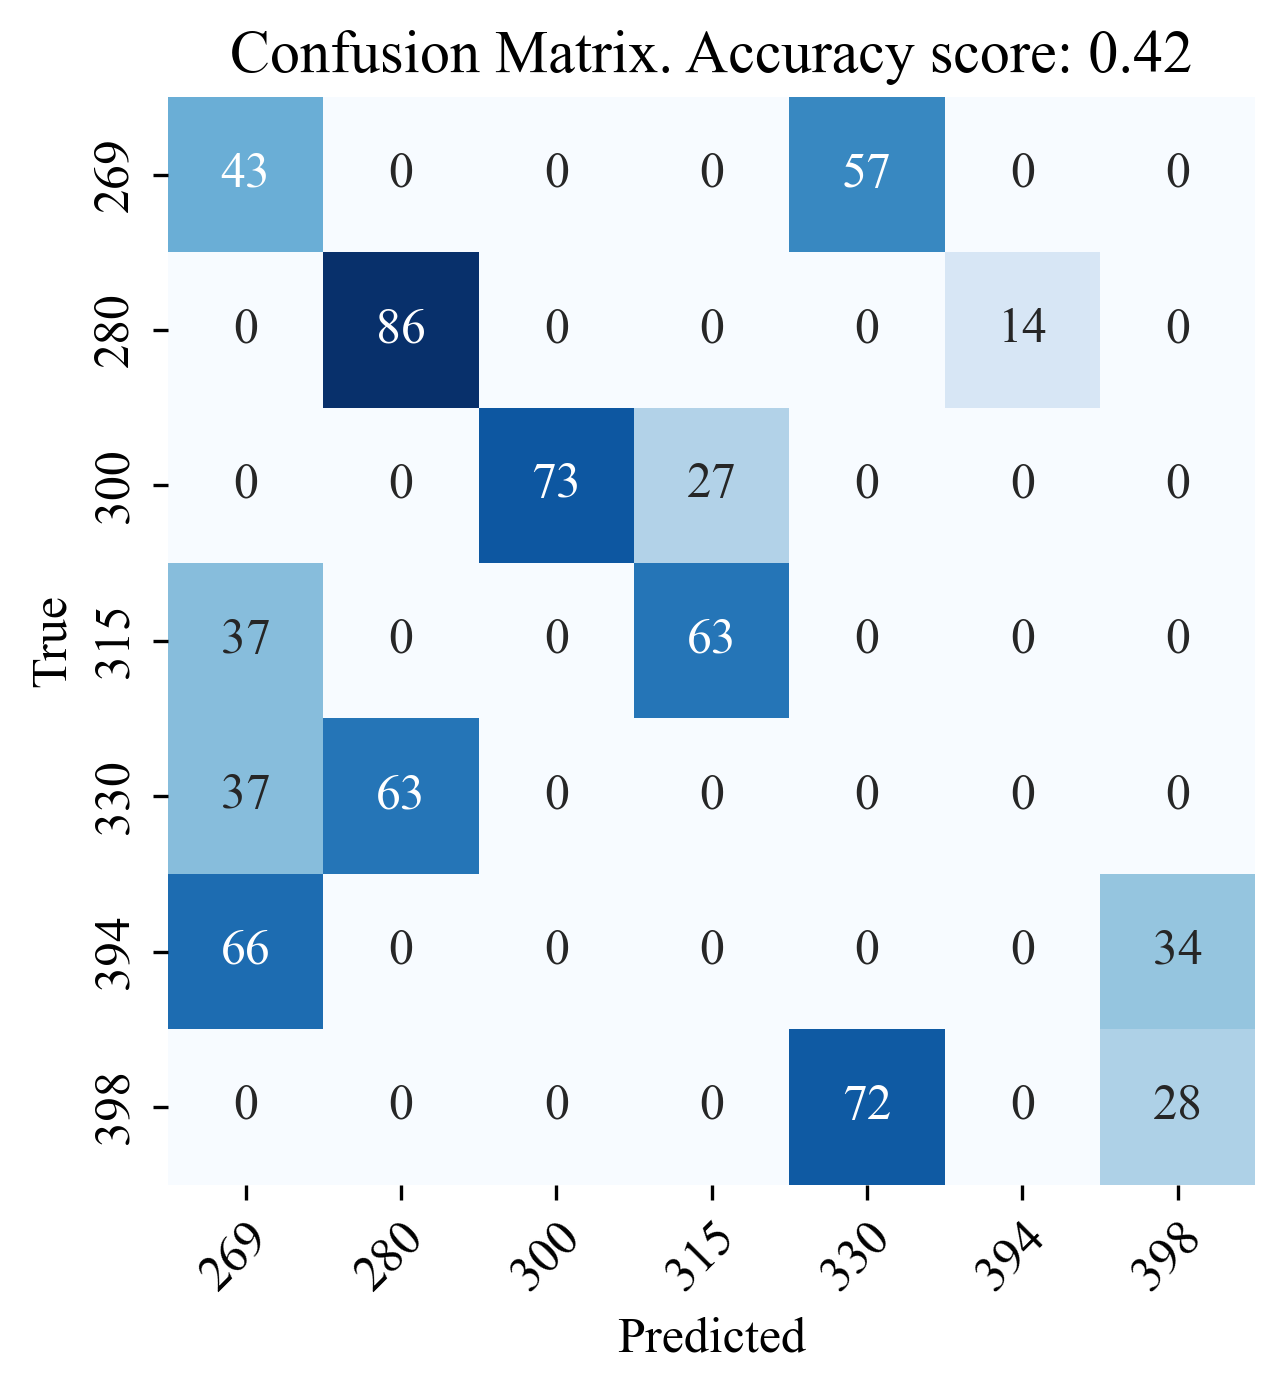

Accuracy score: 0.42
Enrolling device 269: (14, 9)
This is a new device. New ID: 6e73b5bf-b9fe-4978-9638-459a959b1140
Enrolling device 398: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: b6a549b0-fe3f-44a0-95ea-e7b7e0e93fab
Enrolling device 280: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 0c6aaad0-a73a-49c5-ba17-47651394570e
Enrolling device 315: (16, 15)
This is a new device. New ID: 92a3661f-1ca8-43ce-9f66-98773e27fb4d
Enrolling device 394: (20, 14)
This is a new device. New ID: d999a072-46f9-46c0-9a1a-1a4f0e6bb6d6
Enrolling device 300: (15, 20)
This is a new device. New ID: 82f74012-be35-4f76-b3b0-09b4f855b642
Enrolling device 330: (17, 10)
This is a new device. New ID: cdc8447c-8290-40de-8456-7185c47561ee
E1. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (16, 15)
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||

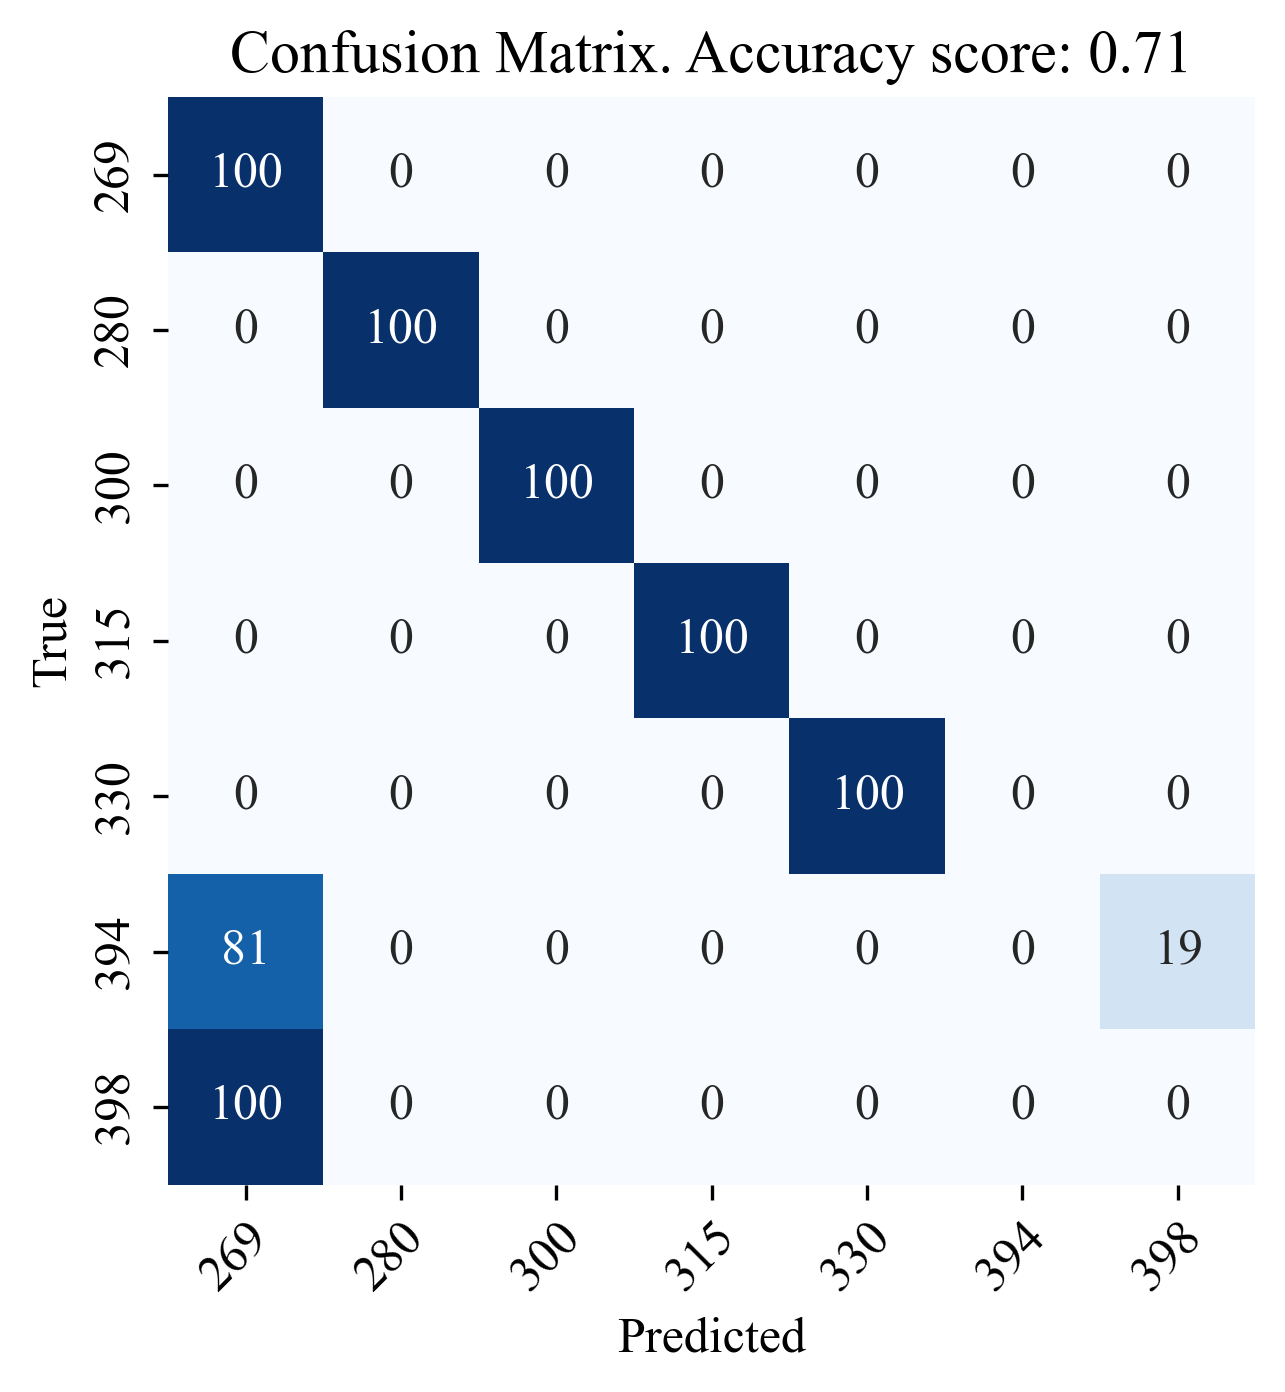

Accuracy score: 0.71
Enrolling device 269: (14, 9)
This is a new device. New ID: d42ec9ad-0ec6-4e82-b45c-deed80a7213b
Enrolling device 398: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 869a8d79-27e9-4611-89df-17a8e380dadc
Enrolling device 280: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 8cfcfd6c-d9df-4233-9f37-c06171d5abcc
Enrolling device 315: (16, 15)
This is a new device. New ID: d7ab1d1d-d87b-4ae9-ba60-eb6a38454547
Enrolling device 394: (20, 14)
This is a new device. New ID: e2a13e26-379c-4aed-9dcf-71e3e71914dd
Enrolling device 300: (15, 20)
This is a new device. New ID: 41766496-1367-4568-baa2-5b64dcff14e3
Enrolling device 330: (17, 10)
This is a new device. New ID: 4a23bb81-9d40-4d85-9b14-6d4fa25cb657
E1. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (16, 15)
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||

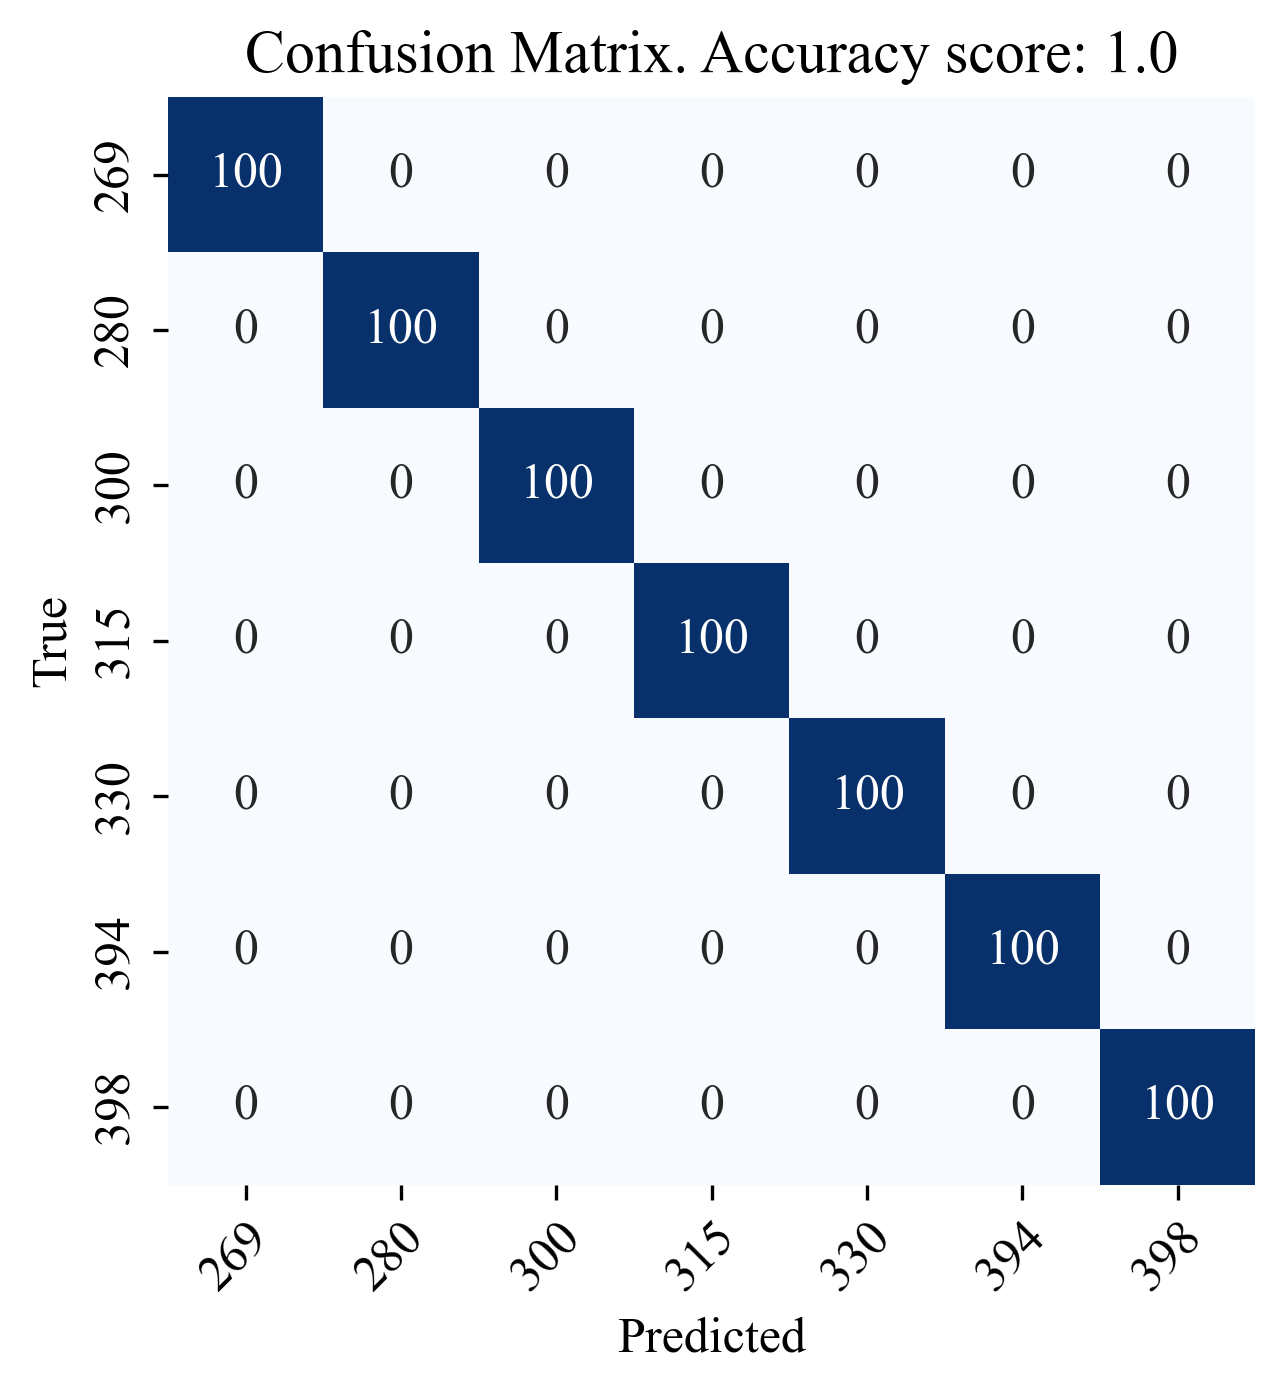

Accuracy score: 1.0


In [41]:
enable_training = False
training_days = 1
augment_multiplier = 2
ch_ind = True
loss_function = 'triplet_loss'
loss_alpha = 1.1
day_enroll_i = 0
day_identify_i = 1
augment_multiplier=2
disjoint_node_ids = [269, 398, 280, 315, 394, 300, 330]

multi_rx_closed_set_accuracies = []

for rx_nodes_max in range(1, 4):
    rx_nodes = RX_NODES[0:rx_nodes_max]

    data_config = DATA_CONFIG = {'dataset_name': DatasetAPI.DATASET_V2V4, 'frame_count_train': 200, 'frame_count_epoch': 2, 'samples_count': 400}
    model_config = { 'loss_type': loss_function, 'alpha': loss_alpha, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': ch_ind }
    fp_api = FingerprintingAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
    eval_api = EvaluationAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

    # 1. Let's train (or load) our models
    models = get_extractor_models(fp_api, training_days, augment_multiplier, enable_training=enable_training, plot_history=False, show_summary=False)

    # 2. Let's evaluate closed-set multi-rx performance
    accuracy = eval_api.evaluate_closed_set_multirx(rx_ids = rx_nodes, 
        epoch_idx_enroll = day_enroll_i, epochs_idx_identify = day_identify_i,
        enroll_device_idx = disjoint_node_ids,
        identify_device_idx = disjoint_node_ids,
        frame_count_enroll = 50, frame_count_identify = 100,
        enroll_threshold = 0, identify_threshold = 100,
        fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_closed_set.eps'))

    multi_rx_closed_set_accuracies.append(accuracy)

### Experiment 5. Multi-RX Multi-day Open-set Fingerprinting

Here, our goal is to evaluate ROC curves on MobRFFI dataset with the following parameters:

1. Trained on Day 1
2. Enrolled on Day 1 (disjoint devices)
3. Identified on Day 1, RX1 (same-day curve)
4. Identified on Day 2, RX in [1, 1+2, 1+2+3] (multi-day curves)

Evaluating: Nrx=1, Enroll Day=1, Identify Day=2
Training the model using data from 1 days.
Data raw: (5800, 1000)
[9, 11, 15, 17, 18, 25, 38, 52, 57, 60, 69, 70, 80, 84, 129, 133, 142, 147, 157, 159, 190, 196, 203, 206, 216, 266, 360, 391, 399]
[11, 17, 25, 38, 52, 57, 60, 129, 133, 147, 157, 159, 190, 196, 206, 216, 266, 391, 399]
Data after filtering: (3800, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (7600, 400)
Final data: (7600, 400)


2024-11-21 20:19:20.506313: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 860 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0


Epoch 1/1000


2024-11-21 20:19:22.008806: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-11-21 20:19:23.747757: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f41b7ff4d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-21 20:19:23.747787: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-21 20:19:23.752178: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1732238363.843532  678846 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


190/190 [==============================] - 9s 24ms/step - loss: 0.1051 - val_loss: 0.0152 - lr: 0.0010
Epoch 2/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0102 - val_loss: 0.0067 - lr: 0.0010
Epoch 3/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0037 - val_loss: 0.0017 - lr: 0.0010
Epoch 4/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0018 - val_loss: 9.5328e-04 - lr: 0.0010
Epoch 5/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0013 - val_loss: 7.3316e-04 - lr: 0.0010
Epoch 6/1000
190/190 [==============================] - 3s 18ms/step - loss: 5.8758e-04 - val_loss: 2.1834e-04 - lr: 0.0010
Epoch 7/1000
190/190 [==============================] - 3s 17ms/step - loss: 3.8336e-04 - val_loss: 5.1276e-04 - lr: 0.0010
Epoch 8/1000
190/190 [==============================] - 3s 17ms/step - loss: 4.6417e-04 - val_loss: 1.2765e-04 - lr: 0.0010
Epoch 9/1000
190/190 [==============================]

Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 28fd72c6-ebe4-4cfd-8562-dbd0206cf12d
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 88afd0ee-86eb-4c1d-87a3-c84255bbc198
Enrolling device: (16, 15)
This is a new device. New ID: f53f18d5-03d3-4dd8-af14-76e688689909
Enrolling device: (20, 14)
This is a new device. New ID: b739f8bc-e674-483c-9fbd-c4ec5f740a59
E1. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (16, 15)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 14)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (15, 20)
|||||||||||||||||||||||||||||||

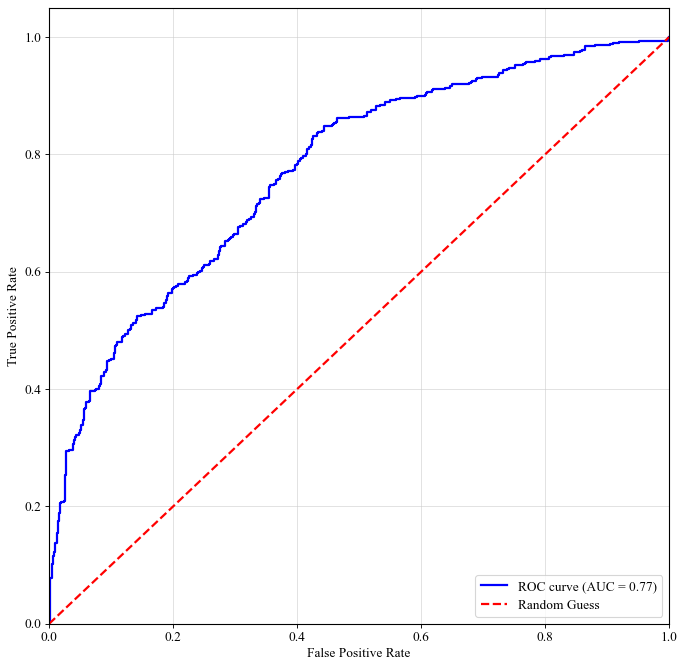

Evaluating: Nrx=2, Enroll Day=1, Identify Day=2
Training the model using data from 1 days.
Data raw: (5800, 1000)
[9, 11, 15, 17, 18, 25, 38, 52, 57, 60, 69, 70, 80, 84, 129, 133, 142, 147, 157, 159, 190, 196, 203, 206, 216, 266, 360, 391, 399]
[11, 17, 25, 38, 52, 57, 60, 129, 133, 147, 157, 159, 190, 196, 206, 216, 266, 391, 399]
Data after filtering: (3800, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (7600, 400)
Final data: (7600, 400)
Epoch 1/1000
190/190 [==============================] - 6s 22ms/step - loss: 0.1051 - val_loss: 0.0152 - lr: 0.0010
Epoch 2/1000
190/190 [==============================] - 3s 18ms/step - loss: 0.0102 - val_loss: 0.0067 - lr: 0.0010
Epoch 3/1000
190/190 [==============================] - 3s 18ms/step - loss: 0.0037 - val_loss: 0.0017 - lr: 0.0010
Epoch 4/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0018 - val_loss: 9.5328e-04 - lr: 0.0010
Epoch 5/1000
190/190 [=========================

2024-11-21 20:24:35.966145: W tensorflow/core/data/root_dataset.cc:342] Optimization loop failed: CANCELLED: Operation was cancelled


This is a new device. New ID: 4fcd4565-3b26-4cf5-83f0-6d9ab4731eff
Enrolling device: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 3f340c44-f411-43ed-aa66-070cd21089ee
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 36fd5812-dc2d-4a2a-8e0a-37ac512734c0
Enrolling device: (16, 15)
This is a new device. New ID: 433aee79-c57c-41b7-87bd-7d509a842d89
Enrolling device: (20, 14)
This is a new device. New ID: f5d1f1f6-d632-4aee-932e-bc87dd6ffd0e
E1. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (16, 15)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 14)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (15, 20)
|||||||||||||||||||||||||||||||

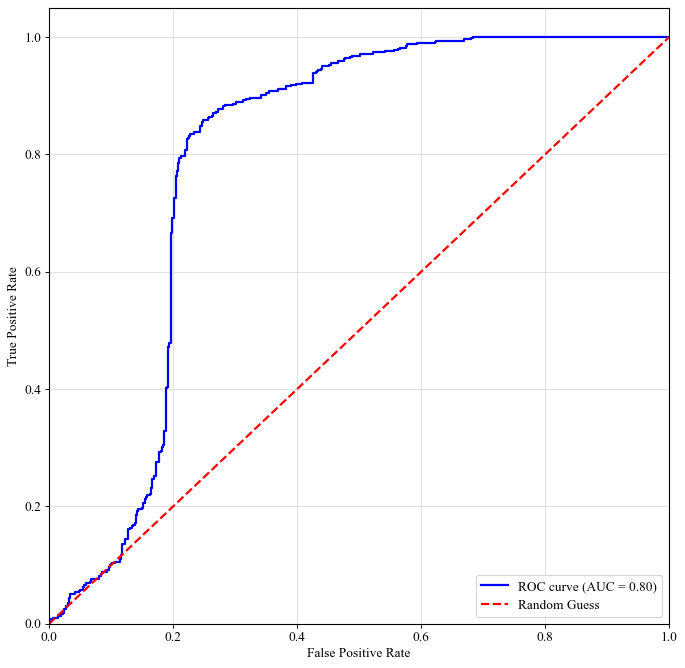

Evaluating: Nrx=3, Enroll Day=1, Identify Day=2
Training the model using data from 1 days.
Data raw: (5800, 1000)
[9, 11, 15, 17, 18, 25, 38, 52, 57, 60, 69, 70, 80, 84, 129, 133, 142, 147, 157, 159, 190, 196, 203, 206, 216, 266, 360, 391, 399]
[11, 17, 25, 38, 52, 57, 60, 129, 133, 147, 157, 159, 190, 196, 206, 216, 266, 391, 399]
Data after filtering: (3800, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (7600, 400)
Final data: (7600, 400)
Epoch 1/1000
190/190 [==============================] - 6s 22ms/step - loss: 0.1051 - val_loss: 0.0152 - lr: 0.0010
Epoch 2/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0102 - val_loss: 0.0067 - lr: 0.0010
Epoch 3/1000
190/190 [==============================] - 3s 18ms/step - loss: 0.0037 - val_loss: 0.0017 - lr: 0.0010
Epoch 4/1000
190/190 [==============================] - 4s 19ms/step - loss: 0.0018 - val_loss: 9.5328e-04 - lr: 0.0010
Epoch 5/1000
190/190 [=========================

Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 625c931f-9f16-4c08-8128-783647b1fcca
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 7ee1eeb0-d1c4-4432-94a1-b66ce55cf322
Enrolling device: (16, 15)
This is a new device. New ID: 1636ff83-c446-4d0b-a3e7-f84b3b2e4058
Enrolling device: (20, 14)
This is a new device. New ID: 0bd49dbb-7f74-4082-b00e-edee1d8afb54
E1. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (16, 15)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (20, 14)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E1. Identifying a device: (15, 20)
|||||||||||||||||||||||||||||||

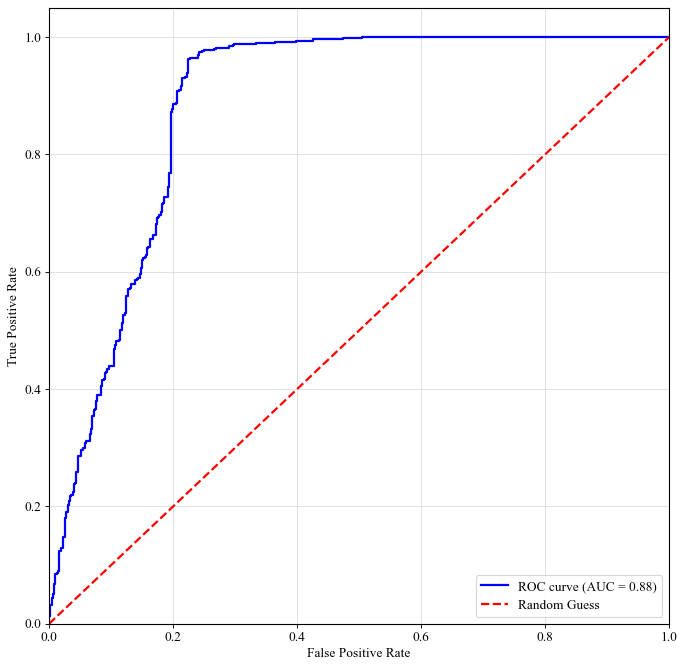

Evaluating: Nrx=1, Enroll Day=1, Identify Day=1
Training the model using data from 1 days.
Data raw: (5800, 1000)
[9, 11, 15, 17, 18, 25, 38, 52, 57, 60, 69, 70, 80, 84, 129, 133, 142, 147, 157, 159, 190, 196, 203, 206, 216, 266, 360, 391, 399]
[11, 17, 25, 38, 52, 57, 60, 129, 133, 147, 157, 159, 190, 196, 206, 216, 266, 391, 399]
Data after filtering: (3800, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (7600, 400)
Final data: (7600, 400)
Epoch 1/1000
190/190 [==============================] - 6s 21ms/step - loss: 0.1051 - val_loss: 0.0152 - lr: 0.0010
Epoch 2/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0102 - val_loss: 0.0067 - lr: 0.0010
Epoch 3/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0037 - val_loss: 0.0017 - lr: 0.0010
Epoch 4/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0018 - val_loss: 9.5328e-04 - lr: 0.0010
Epoch 5/1000
190/190 [=========================

Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: b5af1252-8d5d-4e4a-951e-057702570c92
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: e1268c37-c7d0-41bc-acbc-54f3edc13cb3
Enrolling device: (16, 15)
This is a new device. New ID: df37cdbc-df6a-4476-af7a-24c50d223d95
Enrolling device: (20, 14)
This is a new device. New ID: 54fa9114-b4ab-47ed-a26c-262452e2d8d0
E0. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (16, 15)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (20, 14)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (15, 20)
|||||||||||||||||||||||||||||||

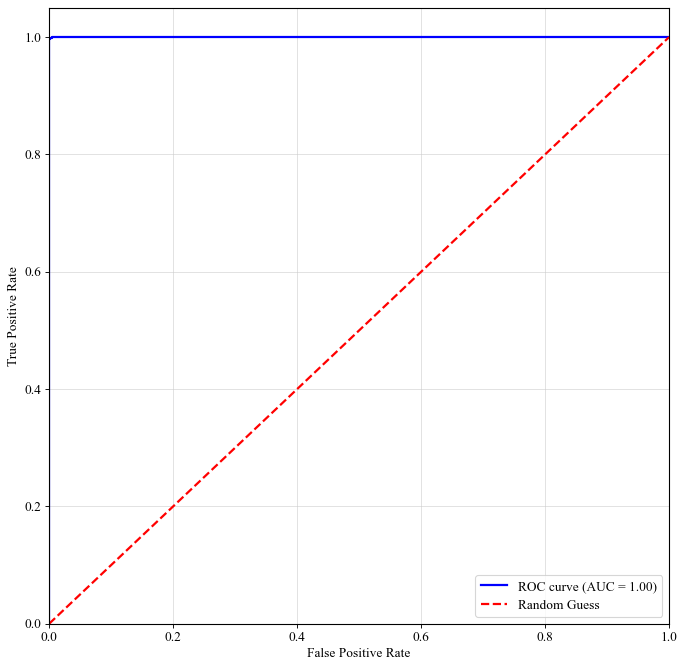

Evaluating: Nrx=2, Enroll Day=1, Identify Day=1
Training the model using data from 1 days.
Data raw: (5800, 1000)
[9, 11, 15, 17, 18, 25, 38, 52, 57, 60, 69, 70, 80, 84, 129, 133, 142, 147, 157, 159, 190, 196, 203, 206, 216, 266, 360, 391, 399]
[11, 17, 25, 38, 52, 57, 60, 129, 133, 147, 157, 159, 190, 196, 206, 216, 266, 391, 399]
Data after filtering: (3800, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (7600, 400)
Final data: (7600, 400)
Epoch 1/1000
190/190 [==============================] - 6s 21ms/step - loss: 0.1051 - val_loss: 0.0152 - lr: 0.0010
Epoch 2/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0102 - val_loss: 0.0067 - lr: 0.0010
Epoch 3/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0037 - val_loss: 0.0017 - lr: 0.0010
Epoch 4/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0018 - val_loss: 9.5328e-04 - lr: 0.0010
Epoch 5/1000
190/190 [=========================

Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: aa1ac4c9-8dd5-4dfe-8b50-6f7108220e4a
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 55a5e371-d93d-472a-8d00-c7a3ab2a3330
Enrolling device: (16, 15)
This is a new device. New ID: 311e148f-18a7-41e2-8c66-02c355aeba48
Enrolling device: (20, 14)
This is a new device. New ID: 77e0d6d1-8c73-40c6-bead-35677834ae63
E0. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (16, 15)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (20, 14)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (15, 20)
|||||||||||||||||||||||||||||||

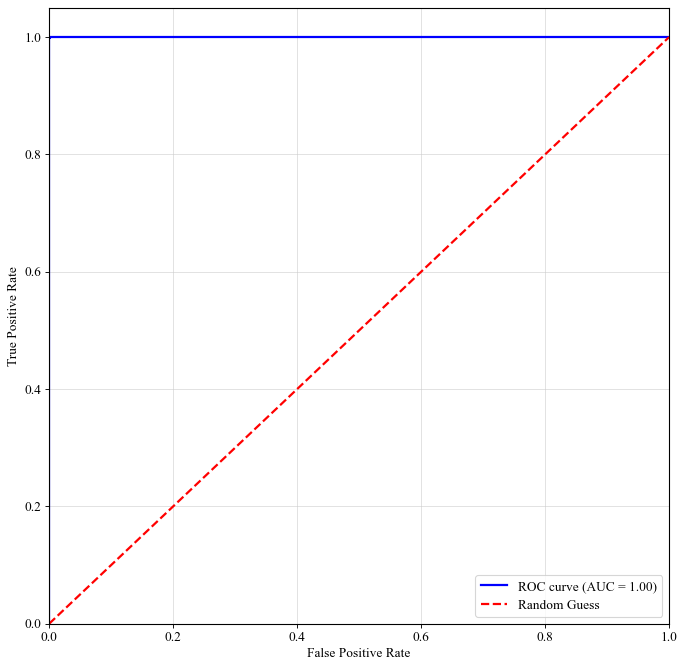

Evaluating: Nrx=3, Enroll Day=1, Identify Day=1
Training the model using data from 1 days.
Data raw: (5800, 1000)
[9, 11, 15, 17, 18, 25, 38, 52, 57, 60, 69, 70, 80, 84, 129, 133, 142, 147, 157, 159, 190, 196, 203, 206, 216, 266, 360, 391, 399]
[11, 17, 25, 38, 52, 57, 60, 129, 133, 147, 157, 159, 190, 196, 206, 216, 266, 391, 399]
Data after filtering: (3800, 400)
Augmenting dataset: x2, randomized CFO adding disabled.
Data after augmentation: (7600, 400)
Final data: (7600, 400)
Epoch 1/1000
190/190 [==============================] - 6s 22ms/step - loss: 0.1051 - val_loss: 0.0152 - lr: 0.0010
Epoch 2/1000
190/190 [==============================] - 3s 17ms/step - loss: 0.0102 - val_loss: 0.0067 - lr: 0.0010
Epoch 3/1000
190/190 [==============================] - 3s 18ms/step - loss: 0.0037 - val_loss: 0.0017 - lr: 0.0010
Epoch 4/1000
190/190 [==============================] - 3s 18ms/step - loss: 0.0018 - val_loss: 9.5328e-04 - lr: 0.0010
Epoch 5/1000
190/190 [=========================

Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 46cb8ade-05fd-41ac-9ded-fef30eaff985
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 277666eb-bce6-4601-b764-1b45787b3fd0
Enrolling device: (16, 15)
This is a new device. New ID: fa1a1aba-ada9-4e59-b955-484b4dd224a5
Enrolling device: (20, 14)
This is a new device. New ID: 2323fbbc-e02e-47bb-b4f1-f5e1eee34e80
E0. Identifying a device: (14, 9)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (20, 18)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (14, 20)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (16, 15)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (20, 14)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
E0. Identifying a device: (15, 20)
|||||||||||||||||||||||||||||||

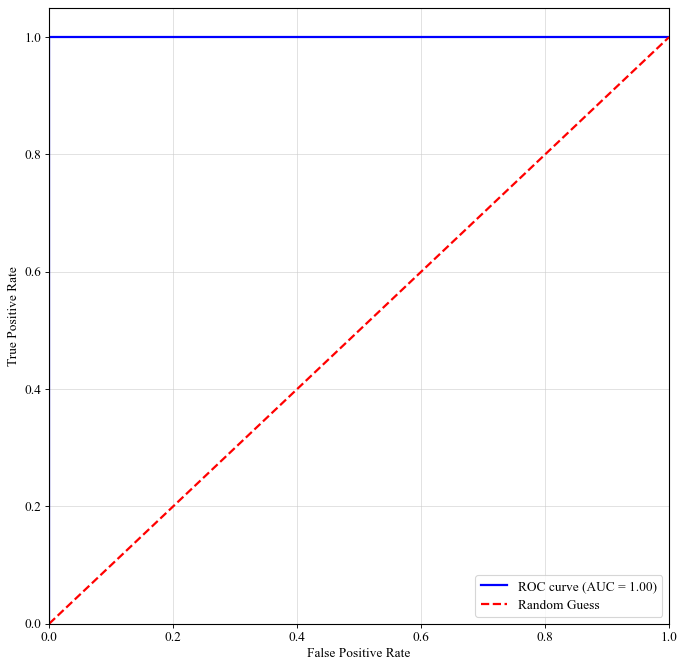

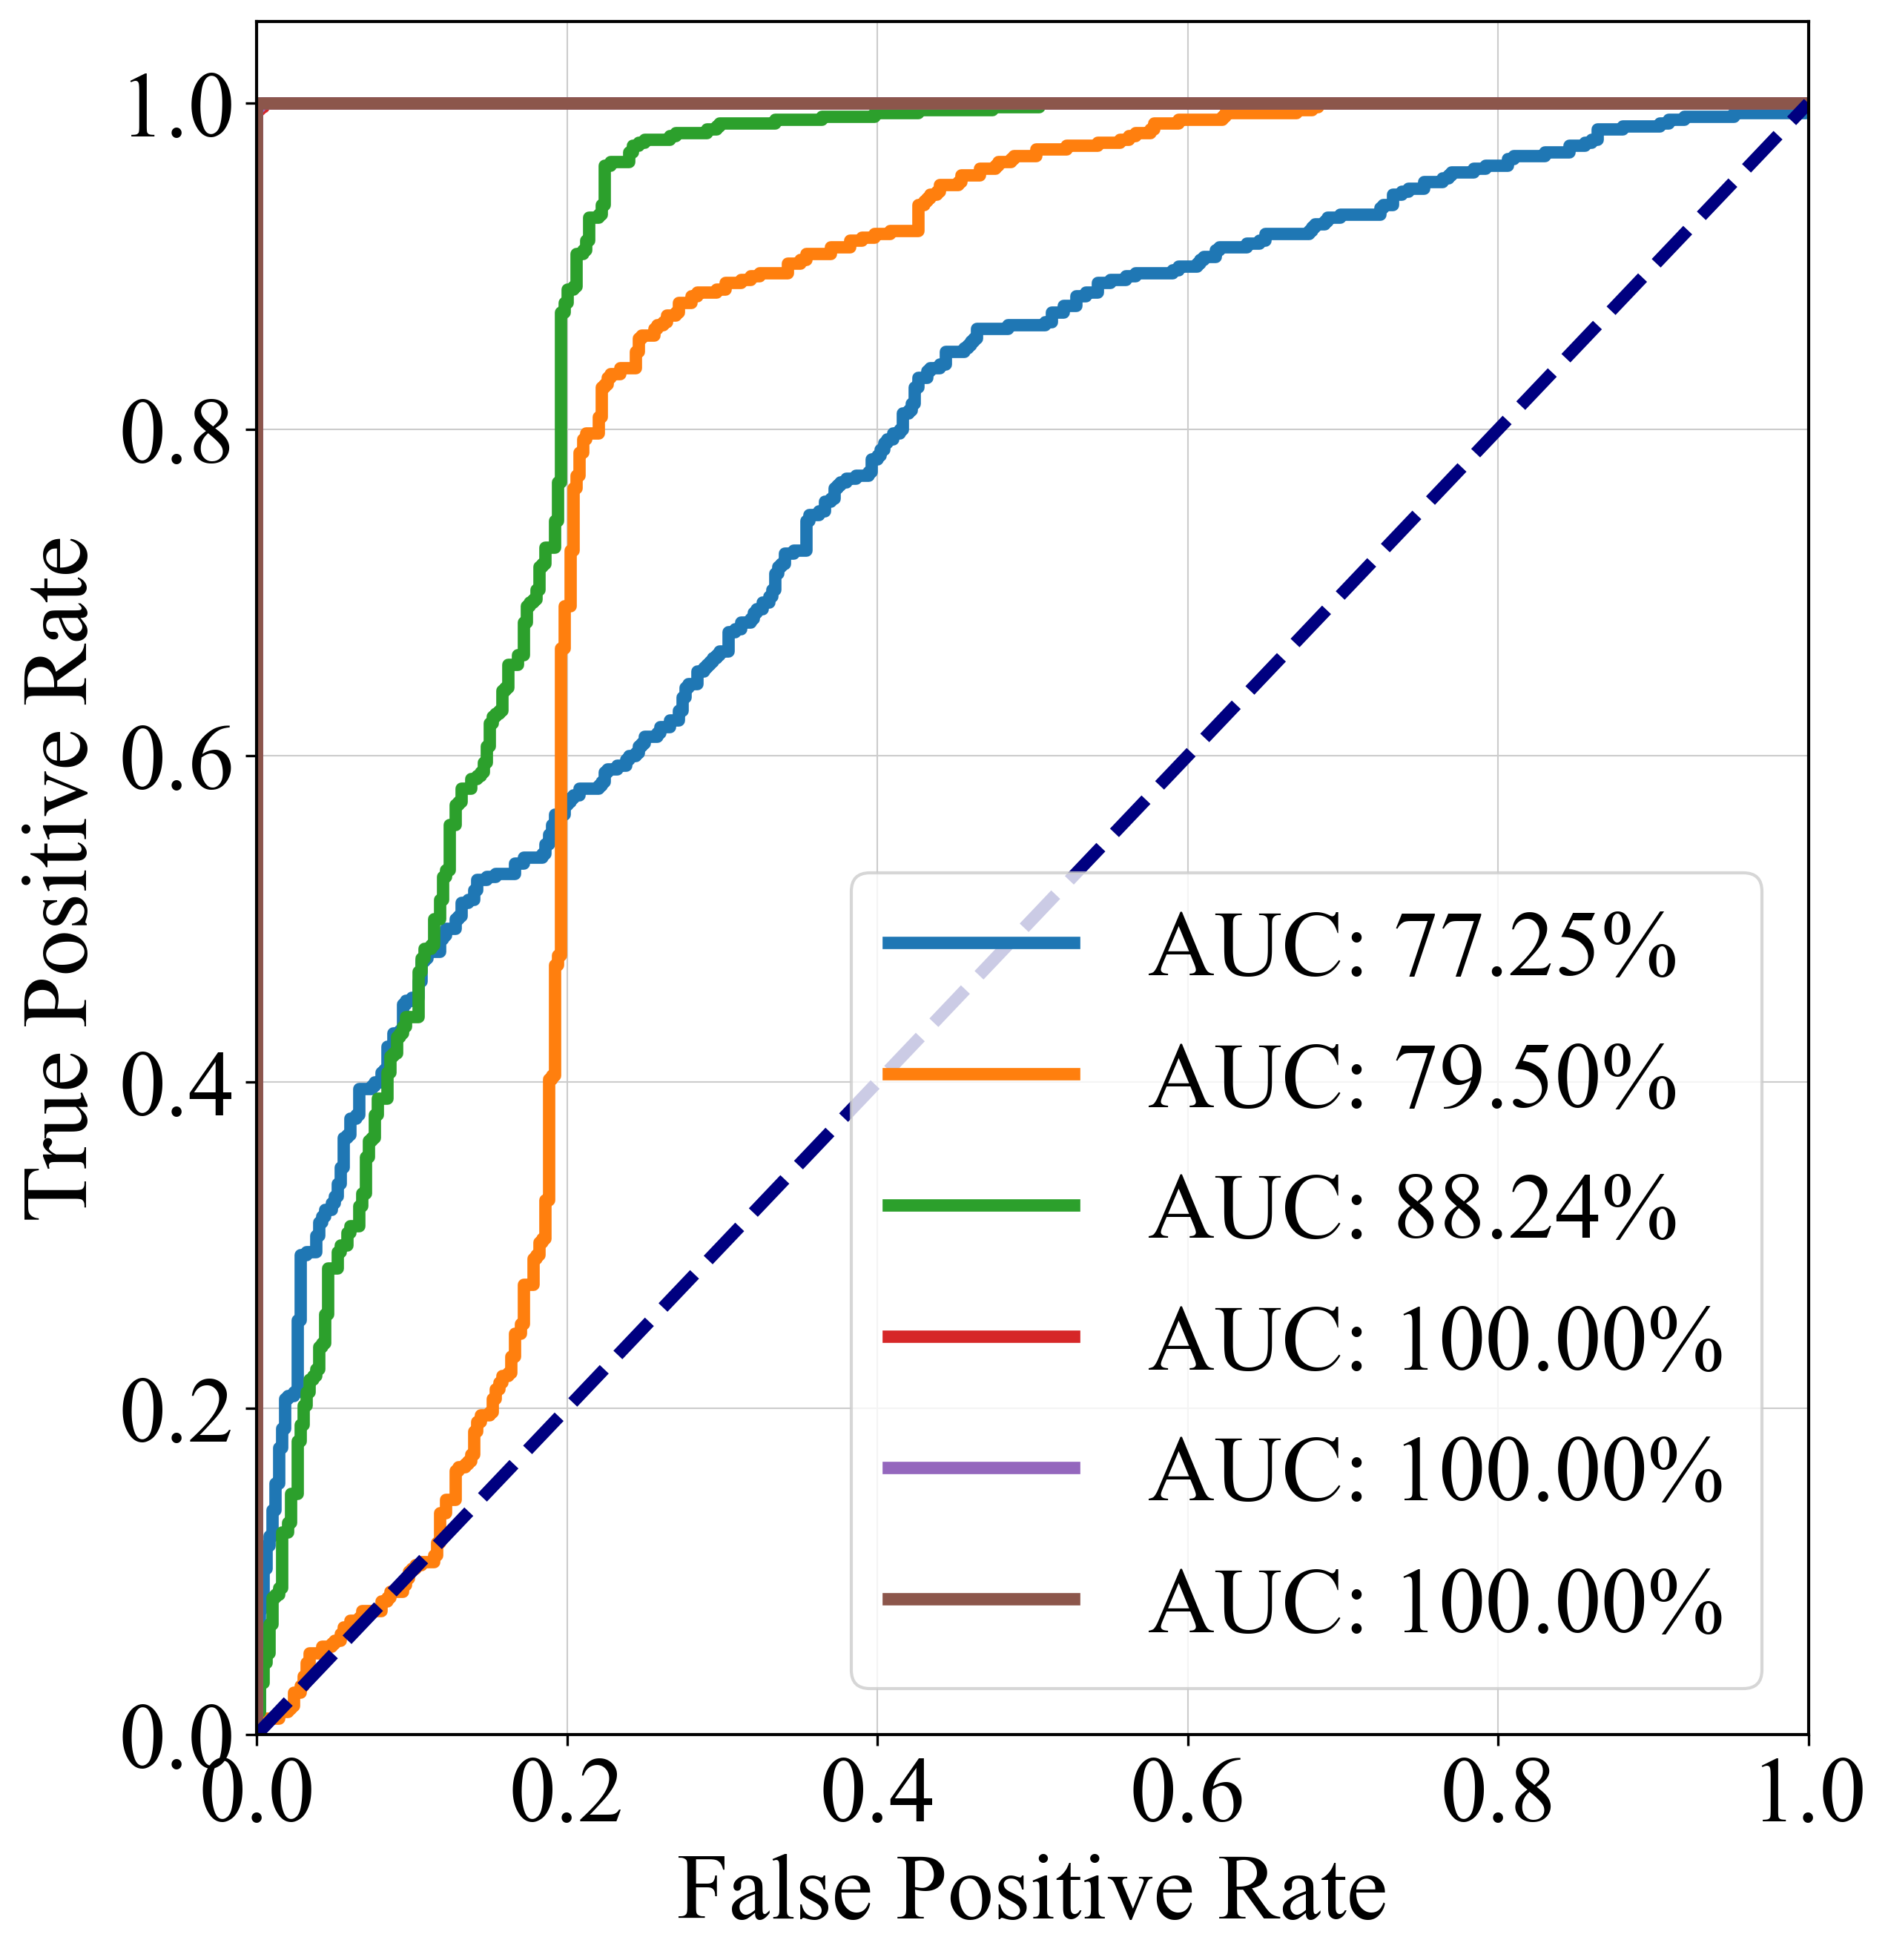

In [6]:
enable_training = True
training_days = 1
augment_multiplier = 2
ch_ind = True
loss_function = 'triplet_loss'
loss_alpha = 1.1
day_enroll_i = 0
disjoint_node_ids_enroll = [269, 398, 280, 315, 394]
disjoint_node_ids_identify = [269, 398, 280, 315, 394, 300, 330, 1, 10, 39]

data_config = {'dataset_name': DatasetAPI.DATASET_V2V4, 'frame_count_train': 200, 'frame_count_epoch': 2, 'samples_count': 400}
model_config = { 'loss_type': loss_function, 'alpha': loss_alpha, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': ch_ind }

roc_curves = [] # comment when running second time to combine ROC curves
for day_identify_i in [1, 0]: # this wont work. gotta change day path in dataset api. this value must remain = 1 at all times.
    for rx_nodes_max in [1, 2, 3]:
        rx_nodes = RX_NODES[0:rx_nodes_max]

        print(f'Evaluating: Nrx={len(rx_nodes)}, Enroll Day={day_enroll_i+1}, Identify Day={day_identify_i+1}')

        fp_api = FingerprintingAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
        eval_api = EvaluationAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
        models = get_extractor_models(fp_api, training_days, augment_multiplier, enable_training=enable_training, plot_history=False, show_summary=False)

        fpr, tpr = eval_api.evaluate_open_set_multirx(rx_ids=rx_nodes, 
            epoch_idx_enroll = day_enroll_i, epochs_idx_identify = day_identify_i,
            enroll_device_idx = disjoint_node_ids_enroll,
            identify_device_idx = disjoint_node_ids_identify,
            frame_count_enroll = 50, frame_count_identify = 100)

        roc_curves.append({'tpr': tpr, 'fpr': fpr, 'info': f'Enrolled on day {day_enroll_i+1}, Identified on day {day_identify_i+1}, Receivers Combined: {len(rx_nodes)}'})

utils.plot_roc_curves(roc_curves)

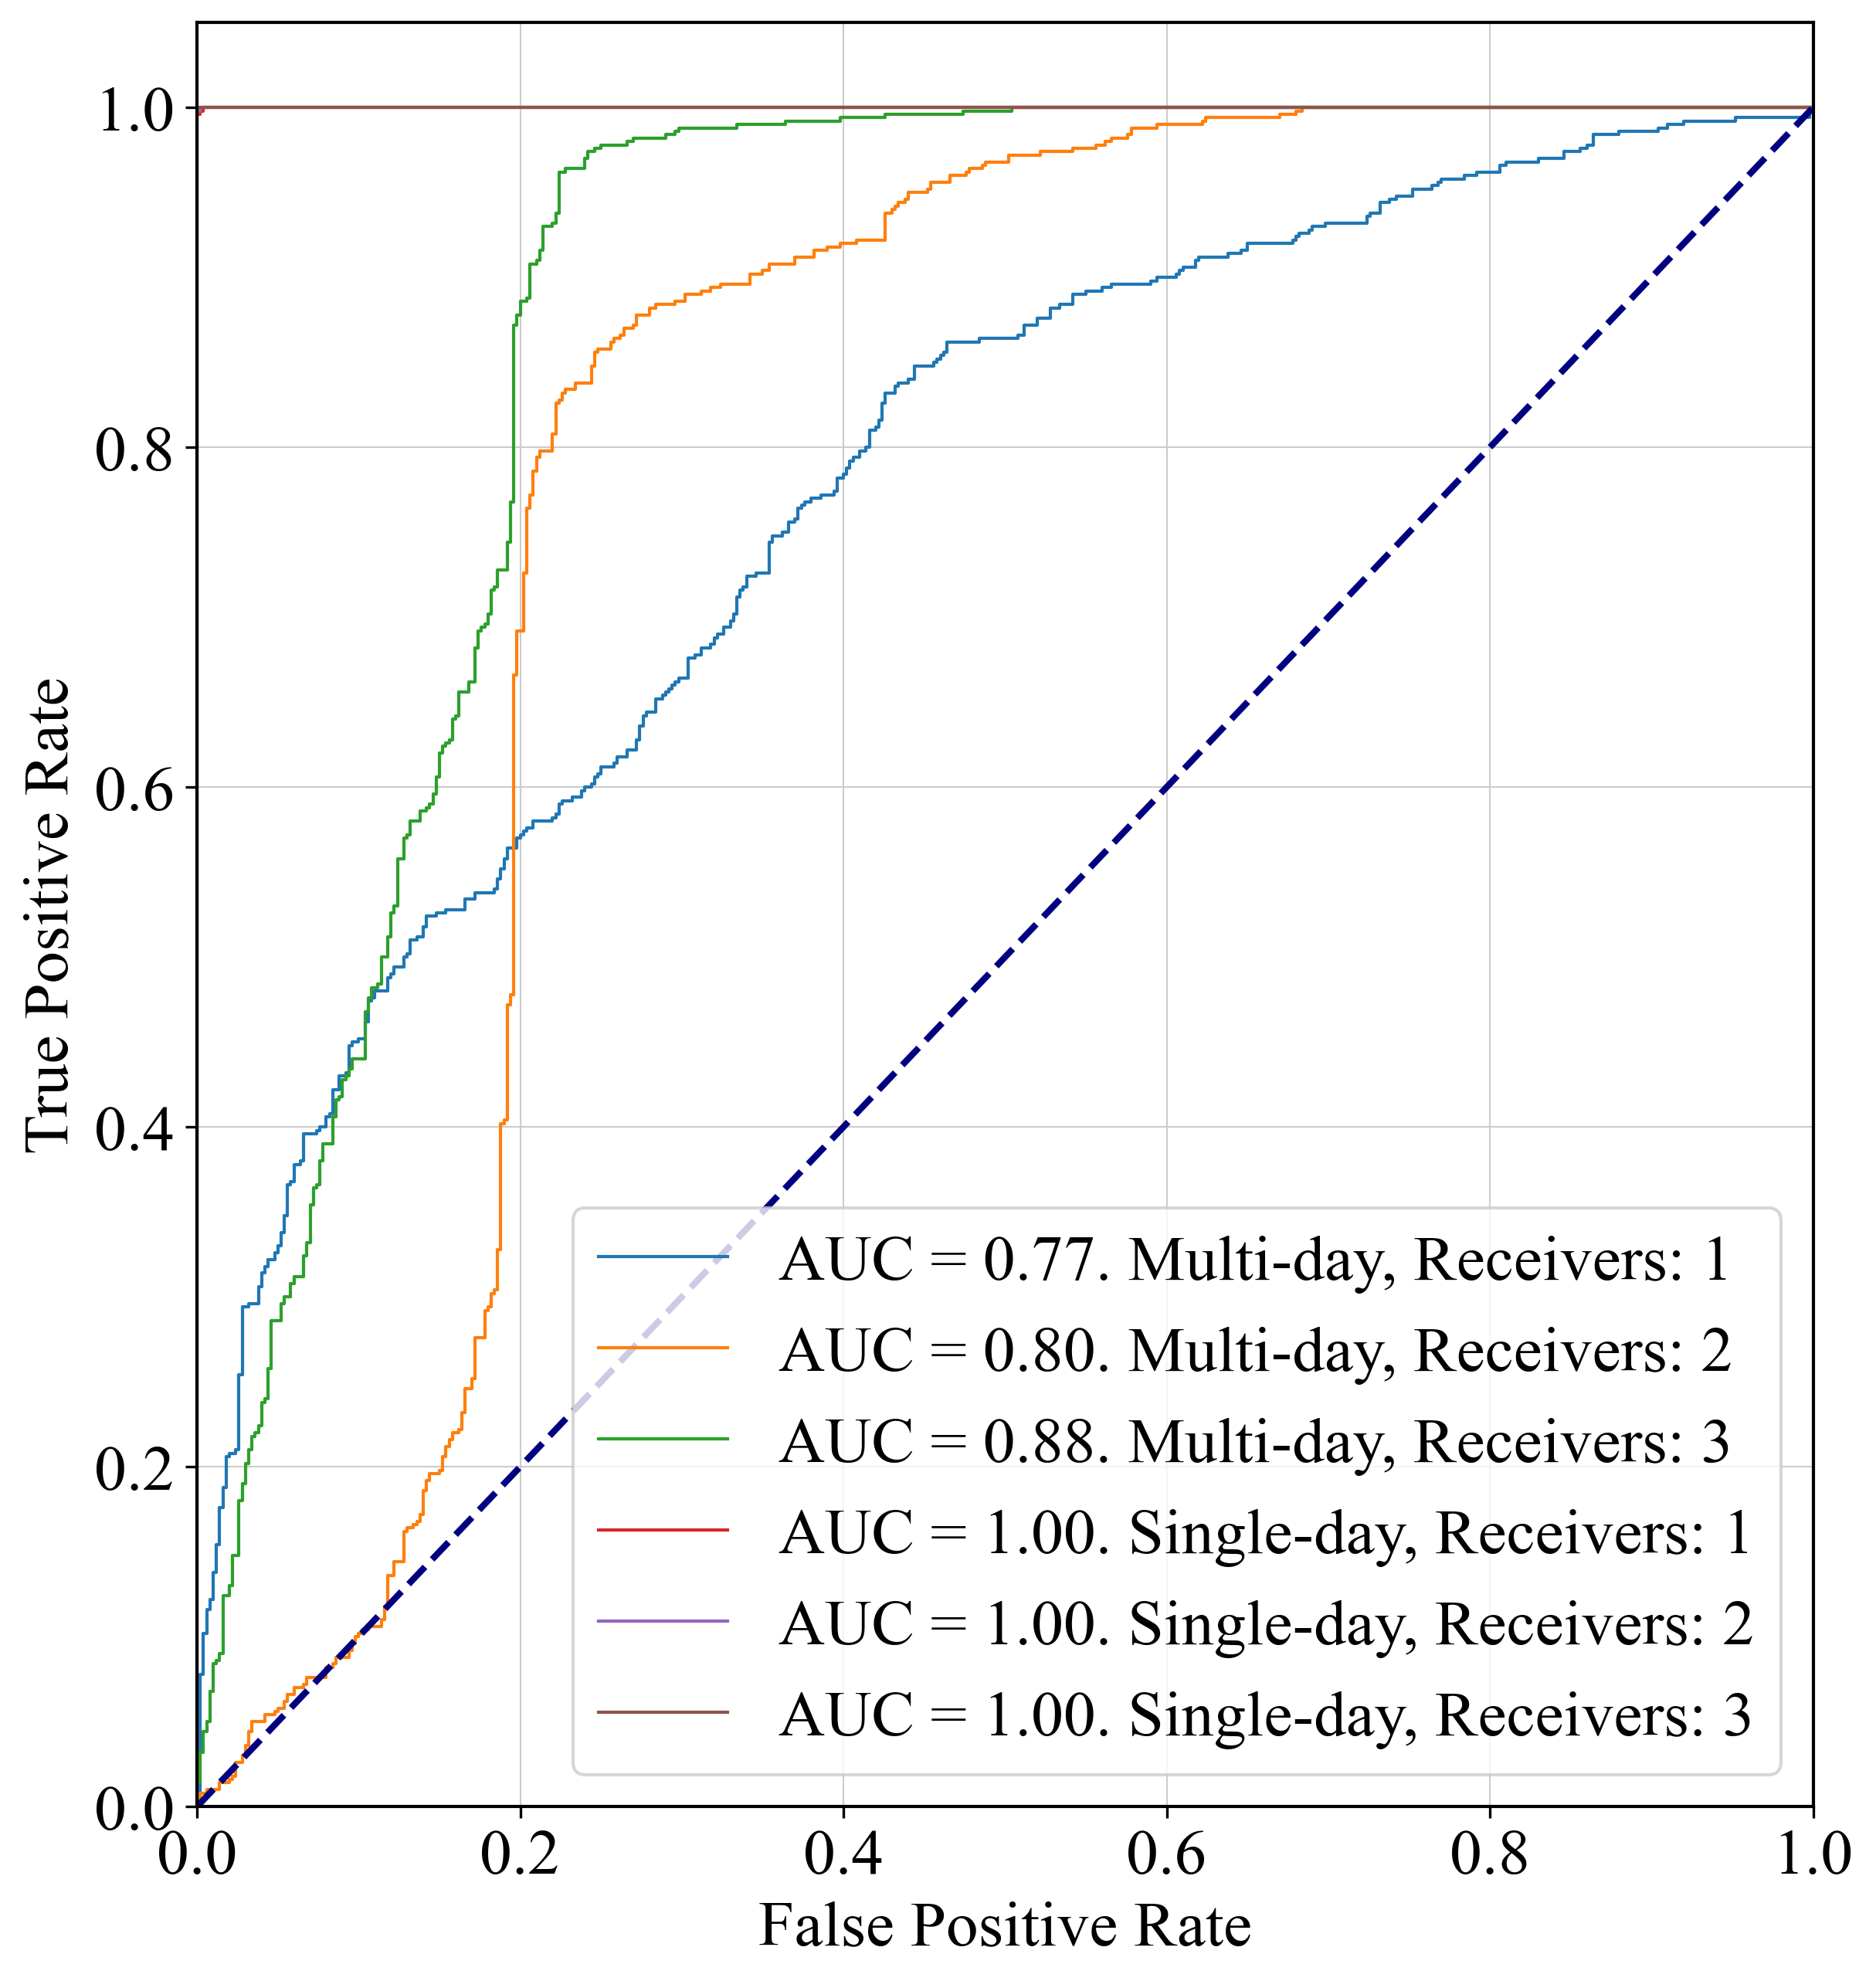

In [ ]:
roc_curves_new = [] 
for item in roc_curves:
    info_new = item['info'].replace('Enrolled on day 1, Identified on day 1', 'Single-day').replace('Enrolled on day 1, Identified on day 2', 'Multi-day').replace('Receivers Combined', 'Receivers')
    roc_curves_new.append({
        'tpr': item['tpr'],
        'fpr': item['fpr'],
        'info': info_new
    })
utils.plot_roc_curves(roc_curves_new)

## 6. That's all, folks!

Thank you for exploring our project! If you found this useful, please consider citing our paper. This would mean the world to our team.

![](https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXhkMmpnZTl0ZmYybWd6NzExMWdxNmY1ZmE4Y2h0d3Zsem96ZG9yMSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/lTpme2Po0hkqI/giphy.gif)

```bibtex
@article{mazokha2024rffi,
  title={RFFI for Mobility Intelligence and MAC Address Derandomization},
  author={Mazokha, Stepan and Bao, Fanchen and Sklivanitis, George and Hallstrom, Jason O},
  journal={TBD},
  year={2024},
  publisher={TBD}
}